# Synthetic Row Generation Notebook 2.0

This notebook is not an extension of the previous version but a restructuring of how each sample is generated. 

Samples generated in this version contain a superscript number in the 18-hole cells. However, the superscripts are not included in the labels.

Each component of the sample is generated individually as images and are later stitched together. A shape (circle, triangle, square) can be added to a single digit (from the 18-hole cell), and then combined with a superscript number that can appear in the upper or lower end of the cell.

For better generalization, all digits are slightly shrinked and translated.

More "randomness" is added in this version:
- Digit position
- Gaps between each digit in double digit numbers
- Gaps between each letter in the header letters
- Starting padding with vertical line
- Digit scale value
- Ending padding
- Shapes

In [1]:
import cv2
from PIL import Image
import os, sys
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import io, filters, color, transform, feature, exposure, segmentation, graph, morphology, restoration, measure
from scipy import ndimage as ndi
import math
import torch
from torchvision import datasets, transforms
import numpy as np

PROJECT_ROOT = Path().resolve().parent
print(PROJECT_ROOT)
print(torch.cuda.get_device_name(torch.cuda.current_device()))
print("Torch version", torch.__version__)

sys.path.insert(0, str(PROJECT_ROOT))

from scripts.constants import TABLE_LINE_INTENSITY

E:\work\Golf\GolfScoreCards
NVIDIA GeForce RTX 2070 Super
Torch version 2.5.1+cu121


## Synthetic sample generation from MNIST and EMNIST datasets

In [2]:
mnist = datasets.MNIST(root='./mnist-emnist_data', train=True, download=True)
digits_imgs = mnist.data.numpy()
digits_labels = mnist.targets.numpy()

emnist = datasets.EMNIST(root='./mnist-emnist_data', split='byclass', train=True, download=True)
letters_imgs = emnist.data.numpy()
letters_labels = emnist.targets.numpy()

### Generating header letters

In [3]:
def get_letter_img(char:str):
    val = ord(char) - ord('A') + 10
    idx = np.random.choice(np.where(letters_labels == val)[0])
    img = letters_imgs[idx]   # EMNIST dataset stores letters rotated 90 degrees and flipped.
    return img.T

def get_header_img(chars:list, tightness=0.7):
    shift = int(28 * tightness)
    w = 28 + (shift * (len(chars) - 1))
    out = np.zeros((32, w), dtype=np.uint8)
    start_y = np.random.randint(0, 4)
    out[start_y:start_y+28, :28] = get_letter_img(chars[0])
    i = 1
    for char in chars[1:]:
        aux = i * shift
        out[start_y:start_y+28, aux:aux+28] = np.maximum(out[start_y:start_y+28, aux:aux+28], get_letter_img(char))
        i += 1
    return out

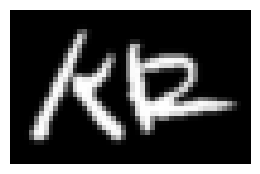

In [10]:
im = get_header_img([chr(np.random.randint(ord('A'), ord('Z'))) for _ in range(np.random.randint(2,4))], tightness=0.8)
plt.figure(figsize=(8,2))
plt.imshow(im, cmap='gray'); plt.axis('off'); plt.show()

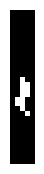

In [11]:
blob_im = np.zeros((32,5), dtype=np.uint8)
start_y = np.random.randint(10,15)
p = 0.65
blob_im[start_y:start_y+8, 1:4] = (np.random.rand(8, 3) < p).astype(np.uint8) * 255
plt.figure(figsize=(8,2))
plt.imshow(blob_im, cmap='gray'); plt.axis('off'); plt.show()

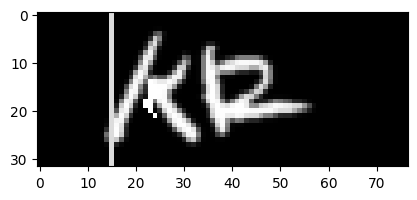

In [160]:
pad = np.zeros((32,28), dtype=np.uint8)
pad_split = np.random.randint(8,24)
padded_im = np.hstack([pad[:,:pad_split], im])
start_x = np.random.randint(12,24)
padded_im[:, start_x:start_x+5] = np.maximum(padded_im[:, start_x:start_x+5], blob_im)
padded_im[:, start_x-6] = 220
padded_im = np.hstack([padded_im, pad[:,pad_split+1:]])
plt.figure(figsize=(8,2))
plt.imshow(padded_im, cmap='gray')#; plt.axis('off'); plt.show()

### Generating numbers

In [500]:
def get_digit_img(val:int):
    """
    Returns 28x28 image with single digit
    """
    idx = np.random.choice(np.where(digits_labels == val)[0])
    return digits_imgs[idx]

def get_double_digit_img(val:int, in_tightness=float):
    """
    Returns 28x? image with double digits
    """
    d1 = get_digit_img(val // 10)
    d2 = get_digit_img(val % 10)
    shift = int(28 * in_tightness)
    canvas = np.zeros((28, 28+shift), dtype=np.uint8)
    canvas[:, :28] = d1
    canvas[:, shift:] = np.maximum(canvas[:, shift:], d2)
    return canvas

def get_1to2digits_img(val:int, tightness=0.5, size=28, rline=False):
    """
    Returns 28x? image with either single or double digits or none
    """
    if val == 0: 
        if size <= 28: im = np.zeros((28,28), dtype=np.uint8)
        elif size > 28: im = np.zeros((size, size), dtype=np.uint8)
    elif len(str(val)) == 1: im = get_digit_img(val)
    else: im = get_double_digit_img(val, tightness)

    if size <= 28: canvas = im
    else:
        ih, iw = im.shape
        canvas = np.zeros((size,iw+6))
        start_h, start_w = np.random.randint(0,size-ih), np.random.randint(0, canvas.shape[1]-iw)
        canvas[start_h:start_h+ih, start_w:start_w+iw] = im
    
    if rline:
        canvas[:, -1] = TABLE_LINE_INTENSITY

    return canvas

def get_handicap_img(val:int, tightness=0.5):
    im = get_1to2digits_img(val=val, tightness=tightness, rline=False)
    im = shrink_and_place(im, width=im.shape[1])  
    canvas = np.zeros((32,im.shape[1]), dtype=np.uint8)
    canvas[2:-2, :] = im
    canvas[:, -1] = TABLE_LINE_INTENSITY
    return canvas

def get_nine_holes_img(vals:list, y_chamb=0, shapes=None):
    """
    Arguments:
        vals:       list of 9 single digits
        y_chamb:    top chamber (0) for superscript, bottom chamber (1)

    Returns 
        32x? image with 9 digits separated by a vertical line.

    Note:   superscripts are generated on the fly, modify to extract labels
            if necessary.
    """
    out = np.zeros((32,0))
    for i, val in enumerate(vals):
        # main digit
        cell_w = np.random.randint(36,40)
        canvas = np.zeros((32,cell_w))
        start_h, start_w = np.random.randint(0,4), np.random.randint(0, cell_w-32) # 32 gives padding=4 for superscript
        digit = get_digit_img(val)
        digit = shrink_and_place(digit, min_scale=0.8, max_scale=1.0)
        if shapes:
            digit = add_hand_drawn_mark(digit, digit.shape[1] // 2, digit.shape[0] // 2, shapes[i]) if shapes[i] != 'none' else digit
        canvas[start_h:start_h+28, start_w:start_w+28] = digit
        ch, cw = canvas.shape

        # superscript
        v = np.random.randint(0,4)
        im = get_digit_img(v)
        small_im = shrink_and_place(im, min_scale=0.3, max_scale=0.5, return_small=True)
        sh, sw = small_im.shape

        # combine main value with superscript
        x_f3rd_start = int(0.60 * cw)
        start_x = np.random.randint(x_f3rd_start, cw - sw)
        y_chamb1_end = int(0.4 * ch) - sh
        y_chamb2_start = int(0.55 * ch)
        if y_chamb == 0:  # top
            start_y = np.random.randint(0, max(1,y_chamb1_end))
        else:   # bottom
            start_y = np.random.randint(y_chamb2_start, ch - sh)
        canvas[start_y:start_y+sh, start_x:start_x+sw] = np.maximum(canvas[start_y:start_y+sh, start_x:start_x+sw], small_im)

        canvas[:, -1] = TABLE_LINE_INTENSITY
        out = np.hstack([out, canvas])
    return out

def get_score_total_img(val:int):
    """
    Returns 32x? image with single or double digits, with a vertical line around the middle 
    of the image
    """
    tightness = np.random.uniform(0.6, 0.8)
    im = get_1to2digits_img(val, tightness)
    cell_w = np.random.randint(36,40)
    start_h, start_w = np.random.randint(0,4), np.random.randint(0, (2*cell_w)-im.shape[1])
    out = np.zeros((32, cell_w*2), dtype=np.uint8)   # initialize canvas (filled with zeros)
    out[start_h:start_h+im.shape[0], start_w:start_w+im.shape[1]] = im
    line_pos = np.random.randint(32,48)
    out[:, line_pos] = TABLE_LINE_INTENSITY
    return out

def shrink_and_place(img, min_scale=0.75, max_scale=0.9, width=28, return_small=False):
    """
    Returns 28x28 image (with single digit)
    """
    H, W = img.shape
    scale = np.random.uniform(min_scale, max_scale)
    new_h = max(1, int(H * scale))
    new_w = max(1, int(W * scale))
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    if return_small: return resized
    canvas = np.zeros((28, width), dtype=img.dtype)
    max_y = 28 - new_h
    max_x = width - new_w
    y0 = np.random.randint(0, max_y + 1)
    x0 = np.random.randint(0, max_x + 1)
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas

def add_hand_drawn_mark(image, center_x, center_y, shape='circle'):
    """Adds a 'wiggly' circle or triangle to the image at a specific location."""
    # Create a copy to avoid modifying the original
    marked_img = image.copy()
    
    # Randomize size and 'wiggle'
    r = np.random.randint(12, 14)
    
    if shape == 'circle':
        axes = (r + np.random.randint(-3,2), r + np.random.randint(-3,2))
        angle = np.random.randint(0,360)
        cv2.ellipse(marked_img, (int(center_x), int(center_y)), axes, angle, 0, 360, 235, 1, lineType=cv2.LINE_AA)
        
    elif shape == 'triangle':
        h = int(r * 1.2)
        pts = np.array([
            [center_x + np.random.randint(-2,3), center_y - h + np.random.randint(-1,2)],
            [center_x - np.random.randint(13,16), center_y + np.random.randint(11,14)],
            [center_x + np.random.randint(13,16), center_y + np.random.randint(11,14)]
        ], np.int32)
        cv2.polylines(marked_img, [pts.reshape((-1,1,2))], isClosed=True, color=255, thickness=1)

    elif shape == 'square':
        side = int(r * 1.0)
        pts = np.array([
            [center_x - side + np.random.randint(-1,1), center_y - side + np.random.randint(-1,1)],
            [center_x + side + np.random.randint(-1,1), center_y - side + np.random.randint(-1,1)],
            [center_x + side + np.random.randint(-1,1), center_y + side + np.random.randint(-1,1)],
            [center_x - side + np.random.randint(-1,1), center_y + side + np.random.randint(-1,1)]
        ], np.int32)
        cv2.polylines(marked_img, [pts.reshape((-1,1,2))], isClosed=True, color=235, thickness=1, lineType=cv2.LINE_AA)
        
    return marked_img

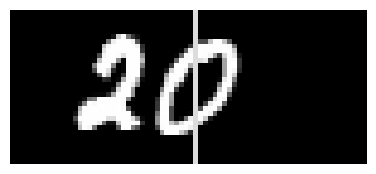

In [373]:
im = get_score_total_img(np.random.randint(15,30))
plt.figure(figsize=(8,2))
plt.imshow(im, cmap='gray'); plt.axis('off'); plt.show()

In [487]:
canvas = np.zeros((32,32), dtype=np.uint8)
aux = canvas[2:-2, 2:-2]
print(aux.shape)

(28, 28)


(32, 42)


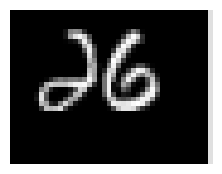

In [381]:
im = get_handicap_img(np.random.randint(2,30))
print(im.shape)
plt.figure(figsize=(8,2))
plt.imshow(im, cmap='gray'); plt.axis('off'); plt.show()

28 42
(32, 48)
4 6
(32, 48)


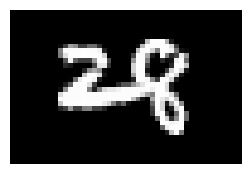

In [458]:
im = get_1to2digits_img(np.random.randint(2,30), size=32)
print(im.shape)
plt.figure(figsize=(8,2))
plt.imshow(im, cmap='gray'); plt.axis('off'); plt.show()

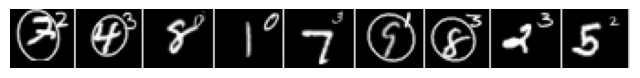

In [497]:
shapes = {'none': '', 'circle': '@', 'triangle': '^', 'square': '+'}
im = get_nine_holes_img(
    vals=[np.random.randint(1, 10) for _ in range(9)], 
    y_chamb=np.random.randint(0,2),
    shapes=[np.random.choice(list(shapes.keys()), p=[0.5, 0.2, 0.15, 0.15]) for _ in range(9)]
    # shapes=[np.random.choice(list(shapes.keys()), p=[0.0, 0.0, 1.0, 0.0]) for _ in range(9)]
)
plt.figure(figsize=(8,2))
plt.imshow(im, cmap='gray'); plt.axis('off'); plt.show()

(32, 40)


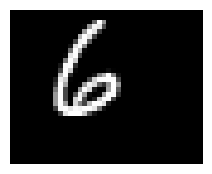

In [74]:
# moving single digit of 28x28 in a 32x40 canvas
im = np.zeros((32,40))
start_h, start_w = np.random.randint(0,4), np.random.randint(0, 40-28)
im[start_h:start_h+28, start_w:start_w+28] = get_digit_img(np.random.randint(0,9))
print(im.shape)
plt.figure(figsize=(8,2))
plt.imshow(im, cmap='gray'); plt.axis('off'); plt.show()

### Generating sample

(32, 983)


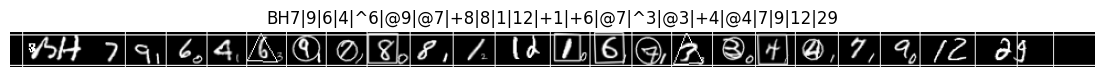

In [508]:
def generate_complex_golf_seq(tightness=0.6, alph_tightness=0.8):
    # Pattern: 2-3 Letters -> 1-2 Digits -> 9 Digits -> 2 Digits -> 9 Digits -> 1-2 Digits -> 2 Digits
    
    # 1. Define the actual string sequence first
    shapes = {'none': '', 'circle': '@', 'triangle': '^', 'square': '+'}
    shape_p = [0.6, 0.2, 0.1, 0.1]
    components = {
        'header':       [chr(np.random.randint(ord('A'), ord('Z'))) for _ in range(np.random.randint(2,4))],
        'handicap':     np.random.randint(0, 20),
        'nine_holes1':  [np.random.randint(1, 10) for _ in range(9)],
        'nine_holes1_shapes':  [np.random.choice(list(shapes.keys()), p=shape_p) for _ in range(9)],
        'nine_sum1':    np.random.randint(10, 16),
        'nine_holes2':  [np.random.randint(1, 10) for _ in range(9)],
        'nine_holes2_shapes':  [np.random.choice(list(shapes.keys()), p=shape_p) for _ in range(9)],
        'nine_sum2':    np.random.randint(10, 16),
        'score_total':  np.random.randint(10, 35)
    }

    label_components = {
        'header_handicap': ''.join(components['header']) + str(components['handicap']) if components['handicap'] > 0 else '',
        'nine_holes1': '|'.join([f"{shapes[components['nine_holes1_shapes'][i]]}{num}" for i, num in enumerate(components['nine_holes1'])]),
        'nine_sum1': str(components['nine_sum1']),
        'nine_holes2': '|'.join([f"{shapes[components['nine_holes2_shapes'][i]]}{num}" for i, num in enumerate(components['nine_holes2'])]),
        'nine_sum2': str(components['nine_sum2']),
        'score_total': str(components['score_total'])
    }

    label_str = '|'.join(list(label_components.values()))

    # 3. Get images for each component
    y_chamb = np.random.randint(0,2)
    img_components = {
        'header':       get_header_img(components['header'], alph_tightness),
        'handicap':     get_handicap_img(components['handicap']),
        'nine_holes1':  get_nine_holes_img(components['nine_holes1'], y_chamb, components['nine_holes1_shapes']),
        'nine_sum1':    get_1to2digits_img(components['nine_sum1'], tightness, 32, True),
        'nine_holes2':  get_nine_holes_img(components['nine_holes2'], y_chamb, components['nine_holes2_shapes']),
        'nine_sum2':    get_1to2digits_img(components['nine_sum2'], tightness, 32, True),
        'score_total':  get_score_total_img(components['score_total'])
    }

    # 4. Stitch up all components
    alph_pad = np.zeros((32,np.random.randint(24,40)), dtype=np.uint8)
    pad_split = np.random.randint(10,34)
    blob_im = np.zeros((32,6), dtype=np.uint8)
    start_y = np.random.randint(10,15)
    p = 0.7
    blob_im[start_y:start_y+8, :] = (np.random.rand(8, 6) < p).astype(np.uint8) * 255
    final_img = np.hstack([alph_pad[:, :pad_split], img_components['header']])
    start_x = np.random.randint(8,20)
    final_img[:, start_x:start_x+6] = np.maximum(final_img[:, start_x:start_x+6], blob_im)
    final_img[:, start_x-6] = TABLE_LINE_INTENSITY
    if len(components['header']) <= 2: final_img = np.hstack([final_img, alph_pad[:, pad_split+1:]])

    for _, img_comp in list(img_components.items())[1:]:
        final_img = np.hstack([final_img, img_comp])

    final_img[:, -np.random.randint(1,10)] = TABLE_LINE_INTENSITY
    final_img = np.hstack([final_img, np.zeros((32,30))])

    # add table row division
    final_img = add_horizontal_cell_line(final_img, np.random.randint(1,4))
    final_img = add_horizontal_cell_line(final_img, np.random.randint(28,32))

    return final_img, label_str

def add_horizontal_cell_line(image, y_pos):
    """Draws a thin vertical line at x_pos."""
    marked_img = image.copy()
    width = marked_img.shape[1]
    # Draw the line from top to bottom
    cv2.line(marked_img, (0, y_pos), (width, y_pos), 255, thickness=1)
    
    return marked_img

# Visualize a sample
img, label = generate_complex_golf_seq()
print(img.shape)
plt.figure(figsize=(14,2))
plt.imshow(img, cmap='gray')
plt.title(label); plt.axis('off'); plt.show()

(32, 1029)


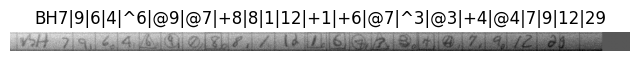

In [509]:
def binary_to_soft_grayscale(
    img, bg_range=(180, 210), text_range=(160, 175), noise_std=2.0, shading_strength=10.0,
    blur_ksize=3, blur_sigma=0.8
):
    """
    Convert a binary image to a soft grayscale image with realistic variation.

    Parameters
    ----------
    img : np.ndarray
        Binary image (H, W), values in {0,1} or {0,255}
        Text pixels are assumed to be foreground (1 or 255).
    bg_range : tuple
        (min, max) grayscale range for background
    text_range : tuple
        (min, max) grayscale range for text
    noise_std : float
        Std of additive Gaussian noise
    shading_strength : float
        Amplitude of low-frequency background shading

    Returns
    -------
    gray : np.ndarray
        Grayscale uint8 image in [0,255]
    """

    img = img.astype(np.float32)

    # Normalize binary to {0,1}
    if img.max() > 1:
        img /= 255.0

    h, w = img.shape

    # Soften binary mask
    if blur_ksize > 1:
        img = cv2.GaussianBlur(img, (blur_ksize, blur_ksize), blur_sigma)

    # Sample per-image gray levels
    bg_gray = np.random.uniform(*bg_range)
    text_gray = np.random.uniform(*text_range)

    # Base mapping
    gray = img * (text_gray - bg_gray) + bg_gray

    # Smooth low-frequency shading
    yy, xx = np.meshgrid(
        np.linspace(-1, 1, h),
        np.linspace(-1, 1, w),
        indexing="ij"
    )
    shading = np.random.uniform(-shading_strength, shading_strength) * (xx + yy)
    gray += shading

    # Add mild noise
    if noise_std > 0:
        gray += np.random.normal(0, noise_std, size=gray.shape)

    # pad sides with 0s
    pad_left = np.random.randint(0, 60)
    pad_right = np.random.randint(0, 60)
    pad_dark = np.random.uniform(160, 175)
    # print("Padded dark pixels intensity: ", pad_dark)

    gray = np.pad(gray, ((0, 0), (pad_left, pad_right)), mode="constant", constant_values=pad_dark)


    return np.clip(gray, 0, 255).astype(np.uint8)

gray_img = binary_to_soft_grayscale(img)
print(gray_img.shape)
plt.figure(figsize=(8,2))
plt.imshow(gray_img, cmap='gray'); plt.title(label); plt.axis('off'); plt.show()

(32, 772)


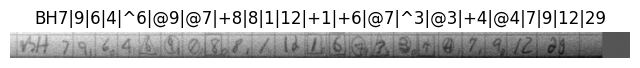

In [510]:
def random_rescale_width(sample, min_scale=0.6, max_scale=1.0):
    H, W = sample.shape
    scale = np.random.uniform(min_scale, max_scale)
    new_w = max(1, int(W * scale))
    resized = cv2.resize(sample, (new_w, H), interpolation=cv2.INTER_AREA)
    return resized

resized = random_rescale_width(gray_img)
print(resized.shape)
plt.figure(figsize=(8,2))
plt.imshow(resized, cmap='gray'); plt.title(label); plt.axis('off'); plt.show()

## Synthetic Sample Bulk Generation

In [513]:
from tqdm import tqdm

def get_last_index(dir_path, level='sample'):
    indices = []
    if level == 'dataset':
        for name in os.listdir(dir_path):
            idx = int(name[-1])
            indices.append(idx)
    else:
        for name in os.listdir(dir_path):
            name = name.split('.')[0]
            idx = int(name.split('_')[1])
            indices.append(idx)
    
    return max(indices) if indices else None

def write_label_file(label_str, f_path, dir):
    loc = os.path.join(dir, f_path)
    with open(loc, "w", encoding="utf-8") as f:
        f.write(label_str)

def bulk_gen_samples(out_dir, N=10000):
    os.makedirs(out_dir, exist_ok=True)
    img_path = os.path.join(out_dir, 'images')
    lbl_path = os.path.join(out_dir, 'labels')
    os.makedirs(img_path, exist_ok=True)
    os.makedirs(lbl_path, exist_ok=True)
    if not os.listdir(img_path): dir_idx = 0
    else: dir_idx = get_last_index(img_path) + 1
    
    for n in tqdm(range(N), desc='Generating synthetic dataset'):
        img, label = generate_complex_golf_seq()
        gray_img = binary_to_soft_grayscale(img)
        resized_img = random_rescale_width(gray_img)
        label_filename = f'image_{dir_idx + n}.txt'
        write_label_file(label, label_filename, lbl_path)
        img_filename = os.path.join(img_path, f'image_{dir_idx + n}.jpeg')
        s_norm = (resized_img - resized_img.min()) / (resized_img.ptp() + 1e-6)
        sample = (s_norm * 255).astype(np.uint8)
        sample = Image.fromarray(sample)
        sample.save(img_filename, format="JPEG")


syn_path = os.path.join(PROJECT_ROOT, 'syn_dataset')
new_set = 'set{k}'
last_i = get_last_index(syn_path, 'dataset')
i = last_i + 1 if last_i is not None else 0
new_set_dir = os.path.join(PROJECT_ROOT, 'syn_dataset', new_set.format(k=i))
print(f"New dataset generated at {new_set_dir}")
bulk_gen_samples(new_set_dir, N=50000)

New dataset generated at E:\work\Golf\GolfScoreCards\syn_dataset\set2


Generating synthetic dataset: 100%|██████████| 50000/50000 [09:45<00:00, 85.40it/s]
